<h1 style="text-align: center;">IMDb Database Analysis Project 2</h1>
<h3 style="text-align: center; font-style: italic;">Exploring Film Release Trends and Runtime Impacts</h3>

## Introduction

This Jupyter Notebook explores the IMDb database using two Python functions: `titles_by_year` and `rating_by_runtime`. These functions are designed to uncover insights into:

- The number of film titles released each year.
- The relationship between movie runtimes and IMDb ratings.

To meet the project requirements, the functions execute advanced SQL queries across multiple tables, perform data transformations within SQL, and present the results through informative visualizations.

This notebook includes:
- A breakdown and explanation of each function.
- Demonstrations with real data examples.
- Highlights of notable patterns and findings observed in the data.

In [ ]:
## Setup and Initial Configuration

Before starting the analysis, we set up the necessary environment and connect to the IMDb database. This section includes the initial code used to:

- Import essential libraries for data analysis and visualization.
- Establish a connection to the IMDb SQLite database.

These steps lay the groundwork for the analytical functions used throughout the notebook.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [23]:
conn = sqlite3.connect("imdb.db")

### Function 1: `titles_by_year`

#### Purpose 
The `titles_by_year` function counts the number of titles released each year within a user-defined range. It accepts three parameters:

- **`conn`**: SQLite database connection.
- **`start_year`**: The starting year for analysis.
- **`end_year`**: The ending year for analysis.

This function helps identify trends in film production, useful for understanding industry growth or declines in response to historical or market factors.

In [ ]:
def titles_by_year(conn, start_year, end_year):
    # Define the SQL query to count the number of titles per year within the given range
    query = f'''
    SELECT
        premiered AS year,
        COUNT(title_id) AS title_count
    FROM titles
    WHERE premiered BETWEEN {start_year} AND {end_year}
      AND premiered IS NOT NULL
    GROUP BY premiered
    ORDER BY premiered;
    '''
    # Execute the query and store the result in a DataFrame
    df = pd.read_sql_query(query, conn)

    # Visualization
    plt.figure(figsize=(12, 6))
    # Create a barplot showing the number of titles released per year
    ax = sns.barplot(data=df, x='year', y='title_count', palette='Blues')
    
    # Add value labels on top of each bar 
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3, fontsize=10)
        
    # Calculate the average number of titles per year
    mean_value = df['title_count'].mean()
    
    # Draw a red dashed horizontal line at the mean value to show the average level
    plt.axhline(mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
    plt.legend(loc='upper left')   # # Add a legend to explain the red line
    plt.title(f'Number of Titles Released Each Year ({start_year}–{end_year})', fontsize=13)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Titles', fontsize=12)

    # Remove the top and right spines (borders) for a cleaner look
    sns.despine()
    plt.tight_layout()
    plt.show()

#### SQL Query

The function executes a SQL query that selects the **premiered year** and counts the number of `title_id` entries from the `titles` table. It:

- Groups the results by year.
- Filters out null values.
- Restricts the data to the specified year range using `start_year` and `end_year`.

The `COUNT` aggregation function is used to efficiently compute the number of titles per year directly within SQL.


#### Visualization

A **Seaborn bar plot** is used to display the number of titles released per year. Key visualization features include:

- Value labels on each bar for clarity.
- A **red dashed line** representing the mean number of titles, helping highlight above or below average years.
- This visual enhancement aids in quick interpretation of trends and anomalies.


#### Parameters

- **`start_year`** and **`end_year`**: These parameters define the range of years for analysis, allowing for **flexible time range selection**, enabling both short- and long-term trend analysis.

#### Example Outputs and Insights

**Example: Year Range 2011–2021**

When analyzing titles released between **2011 and 2021**, the bar plot reveals several key insights:

- From **2011 to 2018**, the number of titles released increased steadily, peaking at **411,772** titles in **2018**.
- A noticeable drop occurred in **2020**, with only **366,207** titles released. This decline is likely due to the global disruption caused by **COVID-19**, which affected production and distribution.
- Despite the 2020 dip, the industry rebounded strongly in **2021**, with **384,976** titles, showing a quick recovery. This rebound may have been driven by the rise of **streaming platforms** and the release of delayed titles.
- Overall, most years after **2015** surpassed the average of **362,677** titles per year, indicating consistent growth in the industry post-2015.

This analysis demonstrates how external events, like the pandemic, can significantly impact production trends, but also shows the industry's resilience in adapting to new distribution channels.

C:\Users\phuon\AppData\Local\Temp\ipykernel_25400\1489240825.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='year', y='title_count', palette='Blues')


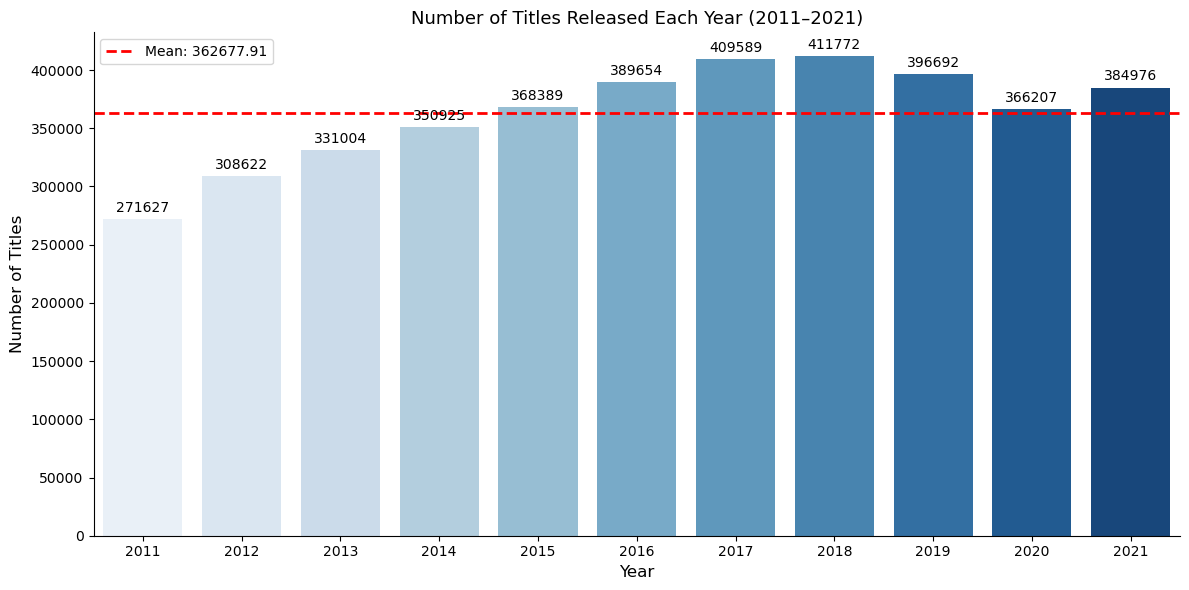

In [35]:
titles_by_year(conn, 2011, 2021)

### Function 2: `rating_by_runtime`

#### Purpose 

The `rating_by_runtime` function explores how movie runtimes affect IMDb ratings, providing insights into audience preferences based on film length. It takes three parameters:

- **`conn`**: SQLite database connection.
- **`min_votes`**: The minimum number of votes a title must have to be included in the analysis, ensuring the rating is statistically reliable.
- **`title_type`**: The type of title to analyze (e.g`'movie'`, `'tvSeries'`).

By filtering out low-vote titles and focusing on specific formats, this function enables a more accurate analysis of how runtime correlates with viewer satisfaction. The insights can be especially useful for **filmmakers and producers** looking to optimize content length for better reception.


In [ ]:
def rating_by_runtime(conn, min_votes, title_type):
    # Writing query to calculate the average rating and number of titles for each runtime category
    query = f"""
    SELECT
      CASE 
         WHEN a.runtime_minutes <= 90 THEN 'Short (<=90 min)'
         WHEN a.runtime_minutes BETWEEN 91 AND 180 THEN 'Medium (91-180 min)'                      
         ELSE 'Long (>180min)'
      END AS runtime_category,                              
      ROUND(AVG(b.rating), 2) AS avg_rating, 
      COUNT(DISTINCT a.title_id) AS num_titles
    FROM titles AS a
    JOIN ratings AS b ON a.title_id = b.title_id
    WHERE a.type = '{title_type}'
      AND a.runtime_minutes IS NOT NULL
      AND b.votes >= {min_votes}
    GROUP BY runtime_category 
    ORDER BY avg_rating DESC; 
    """
    # Execute the query and load the results into a DataFrame
    df = pd.read_sql_query(query, conn)

    # Visualization
    plt.figure(figsize=(8, 5))
    # Create a barplot of average ratings by runtime category
    ax = sns.barplot(data=df, x='runtime_category', y='avg_rating', palette='Blues', width=0.6)

    # Add labels to each bar displaying the average rating
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

    plt.title('Average Movie Rating by Runtime Category', fontsize=13)
    plt.xlabel('Runtime Category', fontsize=12)
    plt.ylabel('Average Rating', fontsize=12)

    # Remove the top and right spines (borders) for a cleaner look
    sns.despine()
    plt.tight_layout()
    plt.show()

#### SQL Query

The function performs a SQL query that:

- Joins the `titles` and `ratings` tables using a common key.
- Filters titles based on `title_type` and a minimum number of votes (`min_votes`) to ensure rating reliability.
- Bins the `runtime_minutes` using a `CASE` statement to group runtimes into logical intervals.
- Calculates the **average rating** and **number of titles** per runtime bin.

The use of `JOIN` and `CASE` allows for complex data manipulation directly within SQL before visualization.


#### Visualization

A **Seaborn bar plot** displays the **average IMDb rating per runtime bin**:

- Each bar represents a runtime group.
- Bars are ordered by runtime for clear interpretability.
- Value labels are added on top of each bar to show precise average ratings.

This visualization helps identify runtime ranges that generally receive higher or lower ratings from audiences.


#### Parameters

- **`min_votes`**: Filters out titles with low vote counts, improving the reliability of average ratings.
- **`title_type`**: Allows filtering by content type (e.g movies, TV series), making the analysis more focused and customizable.

#### Example Outputs and Insights

**Example: Movies, Minimum 100 Votes**

The chart shows that **movies with longer runtimes tend to receive higher average ratings**:

- Films over **180 minutes** have the highest average rating of **7.15**.
- **Medium-length movies** (91–180 minutes) follow with an average rating of **6.12**.
- **Short films** (90 minutes or less) have the lowest average rating of **5.70**.

This trend suggests that **longer movies may offer more depth, character development, or complex storytelling**, which resonates better with audiences and results in higher ratings.

C:\Users\phuon\AppData\Local\Temp\ipykernel_25400\3112886294.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='runtime_category', y='avg_rating', palette='Blues', width=0.6)


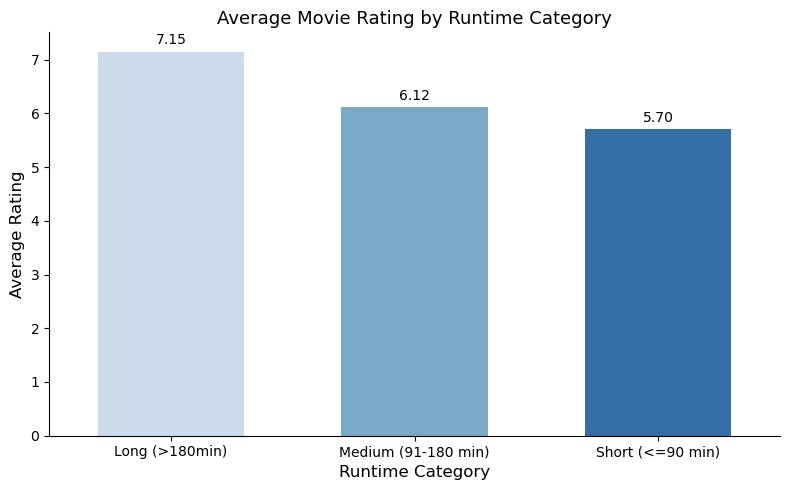

In [48]:
rating_by_runtime(conn, min_votes=100, title_type='movie')

### Conclusion


The SQL-driven functions utilized in this analysis provide critical tools for understanding movie production trends and viewer preferences:

- **`titles_by_year()`**: This function is instrumental in analyzing production trends over time. By counting the number of titles released each year within a specified range, it helps researchers and studios evaluate how content production responds to market dynamics or societal changes.

- **`rating_by_runtime()`**: This function offers valuable insights into viewer preferences based on movie runtime. By examining average ratings across different runtime bins, it can guide production decisions and platform recommendations, ensuring content aligns with audience expectations.

Together, these functions facilitate a data-driven approach to decision-making in the film industry, enabling stakeholders to adapt strategies in response to evolving trends and preferences.

Based on the analysis and examples, two key trends emerge:

1. **Title Release Trends (2011–2021)**  
   From 2011 to 2018, the number of titles released grew steadily, peaking at 411,772 in 2018. A sharp decline occurred in 2020 due to the COVID-19 pandemic, with only 366,207 titles released. However, the industry rebounded quickly in 2021 with 384,976 titles. Most years after 2015 exceeded the average annual release volume of 362,677, indicating a strong and resilient industry recovery driven by factors such as streaming platforms and delayed releases.

2. **Impact of Runtime on Audience Ratings (Movies Only)**  
   The analysis shows that longer movies tend to receive higher average IMDb ratings. Films over 180 minutes have the highest average rating of 7.15, compared to 6.12 for medium-length movies (91–180 minutes) and 5.70 for short films (90 minutes or less). This suggests that audiences may associate longer runtimes with more engaging or higher-quality storytelling.

These insights highlight the industry's ability to adapt and recover, as well as the potential benefits of producing high-quality, longer-form movie content to better meet audience expectations.
